# Pipeline Final de Facturas (YOLO + OCR Flexible)

Este notebook integra de manera automatizada:
1. **Detección con YOLO:** Detección de la región de interés (bounding box de la factura).
2. **Deskew (Corrección de rotación):** Ajuste de ángulo para facturas giradas.
3. **Preprocesamiento:** Aplicación de filtros para mejorar la legibilidad usando las utilidades ya desarrolladas en `src`.
4. **OCR Flexible:** Uso de `EasyOCR` y de `difflib.get_close_matches` para hacer una búsqueda tolerante a errores ortográficos de la palabra `TOTAL`.

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr
import difflib
import re

# Añadir el directorio raíz al path para importar módulos de src
sys.path.append(os.path.abspath('..'))

from src.utils.image_processing import preprocess_image_for_ocr

# Inicializar EasyOCR (usamos inglés y español)
reader = easyocr.Reader(['es', 'en'], gpu=True)

## 1. Carga de Modelo YOLO Preentrenado

Para cumplir con el requerimiento de detectar la factura en la imagen emplearemos YOLO.
Como no disponemos de un modelo especializado para "facturas" en la carpeta `models`, cargaremos `yolov8n.pt`. Alternativamente, en un entorno productivo se debe cargar un modelo entrenado en documentos (por ejemplo un modelo de Roboflow o un YOLO fine-tuneado en facturas).

El código a continuación está preparado para cargar cualquier peso `.pt`:

In [2]:
def cargar_y_detectar_factura(img_path, modelo_path='yolov8n.pt'):
    """
    Detecta la región de la factura dentro de la imagen. 
    Devuelve la imagen original y la región (bounding box) recortada.
    """
    print(f"Cargando modelo YOLO desde: {modelo_path}...")
    model = YOLO(modelo_path)
    
    img_original = cv2.imread(img_path)
    if img_original is None:
        raise ValueError(f"No se pudo cargar la imagen: {img_path}")
    
    # Predecir sobre la imagen
    results = model(img_original)
    
    # Extraer el Bounding Box con mayor confianza.
    # En el caso de yolov8n base, puede que detecte objetos como 'book'. 
    # Asumimos que el objeto de mayor tamaño o mayor confianza es la factura.
    cajas = results[0].boxes.xyxy.cpu().numpy()  # Cajas en formato [x1, y1, x2, y2]
    confianzas = results[0].boxes.conf.cpu().numpy()
    
    if len(cajas) > 0:
        # Tomamos la detección con la máxima confianza
        idx_mejor = np.argmax(confianzas)
        x1, y1, x2, y2 = map(int, cajas[idx_mejor])
        
        # Recortar la región detectada
        img_recortada = img_original[y1:y2, x1:x2]
        print(f"Factura detectada y recortada (Confianza: {confianzas[idx_mejor]:.2f})")
        return img_original, img_recortada
    else:
        print("YOLO no detectó ninguna caja clara. Se retornará la imagen completa como región facturada.")
        return img_original, img_original.copy()

## 2. Deskew (Corrección de Rotación)

Las facturas fotografiadas pueden estar rotadas. Aquí empleamos detección de bordes y líneas (o de contornos) para encontrar el ángulo de rotación general del documento y enderezarlo.

In [3]:
def deskew_image(image):
    """
    Calcula el ángulo de inclinación de los elementos en la imagen usando minAreaRect sobre contornos 
    y corrige la rotación.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Umbralizado e inversión
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    
    # Buscar coordenadas de píxeles activos (texto mayormente)
    coords = np.column_stack(np.where(thresh > 0))
    if len(coords) == 0:
        return image
        
    angle = cv2.minAreaRect(coords)[-1]
    
    # Ajustar el ángulo de convención de OpenCV
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
        
    # Si el ángulo es muy pequeño, asumimos que ya está bien
    if abs(angle) < 1.0 or abs(angle) > 40:
        return image
        
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Rotamos
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    print(f"Imagen rotada corregida en {angle:.2f} grados.")
    return rotated

## 3. Extracción OCR Flexible

La función realiza la extracción del total utilizando un "fuzzy matching" (coincidencia aproximada) sobre el texto escaneado para encontrar "TOTAL" incluso si el OCR lee "TOTAI", "T0TAL", etc.

In [4]:
def OCR_flexible_total(img_preprocesada):
    """
    Pasa la imagen por el OCR de EasyOCR y busca de forma flexible 
    la palabra TOTAL y el valor correspondiente.
    """
    # 1. Leer texto de la imagen completa (detail=0 para devolver solo la string)
    resultados_ocr = reader.readtext(img_preprocesada, detail=0)
    
    # Limpiar textos como Total Qty etc
    resultados_ocr = [text for text in resultados_ocr if "Qty" not in text.upper() and "Items" not in text.upper()]
    
    # Palabras objetivo y variaciones
    target_words = ["TOTAL", "AMOUNT", "DUE", "TOTAI", "T0TAL", "TL"]
    
    regex_numero = re.compile(r'([$€£]?\s*\d+[\.,\s]*\d*)')
    
    for idx, texto in enumerate(resultados_ocr):
        # Utilizamos difflib para ver si hay una coincidencia aproximada con alguna de las variaciones del Total
        palabras = texto.upper().split()
        matches = []
        for palabra in palabras:
            # cutoff bajo (0.6) para permitir errores OCR considerables
            match = difflib.get_close_matches(palabra, target_words, n=1, cutoff=0.6)
            if match:
                matches.append(match[0])

        if matches:
            # Hemos encontrado una palabra parecida a TOTAL en esta línea del OCR.
            # Vamos a buscar el número asociado (en esta misma línea o en las 3 siguientes)
            texto_buscar = texto + " " + " ".join(resultados_ocr[idx+1:idx+4])
            
            # Extraer posibles cantidades
            num_matches = regex_numero.findall(texto_buscar)
            valid_numbers = []
            for match_str in num_matches:
                clean_num = re.sub(r'[^\d\.]', '', match_str.replace(',', '.'))
                if clean_num:
                    try:
                        valid_numbers.append(float(clean_num))
                    except ValueError:
                        pass
            
            if valid_numbers:
                max_val = max(valid_numbers)
                print(f"✔ Coincidencia OCR Difusa encontrada en el texto '{texto}' como {matches[0]}.")
                print(f"✔ Total Numérico detectado: {max_val}")
                return max_val
                
    print("❌ No se encontró ningún 'TOTAL' en el documento.")
    return None

## 4. Pipeline Final Unificado

Agrupamos todos los pasos:

In [5]:
def ejecutar_pipeline_completo(img_path):
    print("="*50)
    print(f"Procesando imagen: {os.path.basename(img_path)}")
    print("="*50)
    
    # Paso 1: YOLO
    # Nota: Instanciamos yolov8n.pt que es el predeterminado general. 
    # Ideal para empezar a testear si no hay uno fino.
    try: 
        img_orig, roi = cargar_y_detectar_factura(img_path, 'yolov8n.pt')
    except Exception as e:
        print(f"Fallo en YOLO: {e}, cargando imagen normal")
        img_orig = cv2.imread(img_path)
        roi = img_orig.copy()
        
    # Paso 2: Deskew
    roi_recta = deskew_image(roi)
    
    # Paso 3: Preprocesamiento src (Mejora visual)
    roi_preprocesada = preprocess_image_for_ocr(roi_recta)
    
    # Paso 4: OCR Flexible
    total = OCR_flexible_total(roi_preprocesada)
    
    # Mostrar resultados por pantalla
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(roi_recta, cv2.COLOR_BGR2RGB))
    plt.title("Deskewed + YOLO Crop")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(roi_preprocesada, cmap='gray')
    plt.title("Preprocesado OCR\n(Tokens buscados: TOTAL)")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return total

## Prueba Rápida

Ejecución sobre una muestra del raw data (Ajusta la ruta según sea necesario):

Procesando imagen: cord_receipt_000.jpg
Cargando modelo YOLO desde: yolov8n.pt...


0: 640x448 (no detections), 209.7ms


Speed: 30.6ms preprocess, 209.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 448)


YOLO no detectó ninguna caja clara. Se retornará la imagen completa como región facturada.


❌ No se encontró ningún 'TOTAL' en el documento.


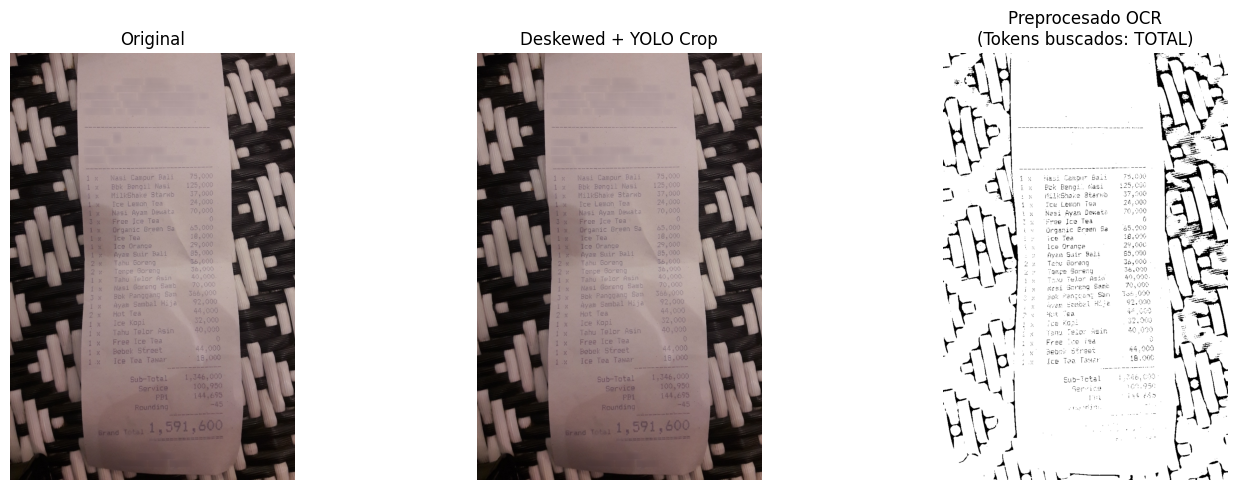

In [6]:
# Prueba de integración (Cambiar la ruta si se requiere)
raw_dir = '../data/raw'
if os.path.exists(raw_dir):
    # Buscar la primera imagen jpg
    imagenes = [f for f in os.listdir(raw_dir) if f.endswith('.jpg')]
    if len(imagenes) > 0:
        img_prueba = os.path.join(raw_dir, imagenes[0])
        ejecutar_pipeline_completo(img_prueba)
    else:
        print(f"No se encontraron imágenes en {raw_dir}")
else:
    print(f"Directorio {raw_dir} no encontrado.")